# Emotion Recognition from Speech

**Group Members:** JoshaLynn · Janil · Diego · Tina

The goal here is pretty straightforward — can we train a model to figure out what emotion
someone is feeling just from how they speak? We're using the RAVDESS dataset, which has
professional actors performing 8 different emotions, and we'll see how well a classic
SVM classifier can tell them apart.

We also try two things to see if we can push the accuracy higher:
- Breaking results down by **intensity** (normal vs strong) to see where the model struggles
- **Grouping similar emotions** together to see if a coarser classifier does better

**Notebook flow:**
1. Load & preprocess audio
2. Exploratory data analysis
3. Feature extraction
4. Train/test split (by actor, not randomly)
5. SVM classifier — main model
6. Intensity breakdown
7. Emotion grouping experiment
8. Unsupervised exploration (LDA + KMeans)

## 1. Environment Setup

In [ ]:
!pip -q install gdown librosa soundfile

## 2. Imports
Everything in one place so nothing mysteriously appears later.

In [ ]:
import os, glob, random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from IPython.display import Audio, display, Markdown

# Fix the random seed so results are reproducible every run
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("Ready. Seed:", SEED)

Ready. Seed: 42


## 3. Download the Dataset

We're using **RAVDESS** — 24 professional actors (12M, 12F) each performing
8 emotions at two intensity levels. All recordings are clean studio audio,
which makes it a good starting point before dealing with noisy real-world speech.

The `if not exists` checks mean this only downloads once — re-running the cell won't re-download.

In [ ]:
DATA_ZIP = "actors_speech.zip"
DATA_DIR = "actors_speech"

if not os.path.exists(DATA_ZIP):
    !gdown --fuzzy "https://drive.google.com/file/d/1Oucj9aJ5ngRK5OXuxgxuVY3AfrJ-L00X/view?usp=sharing" -O {DATA_ZIP}

if not os.path.exists(DATA_DIR):
    !unzip -q {DATA_ZIP} -d {DATA_DIR}

print("Dataset ready:", os.path.exists(DATA_DIR))
print("Contents:", os.listdir(DATA_DIR)[:10])

Downloading...
From (original): https://drive.google.com/uc?id=1Oucj9aJ5ngRK5OXuxgxuVY3AfrJ-L00X
From (redirected): https://drive.google.com/uc?id=1Oucj9aJ5ngRK5OXuxgxuVY3AfrJ-L00X&confirm=t&uuid=3158cab1-0229-45f5-9c4d-11997c78c0f5
To: /content/actors_speech.zip
100% 208M/208M [00:02<00:00, 86.9MB/s]
Dataset ready: True
Contents: ['Actor_07', 'Actor_09', 'Actor_10', 'Actor_13', 'Actor_03', 'Actor_15', 'Actor_01', 'Actor_22', 'Actor_23', 'Actor_16']


## 4. Audio Preprocessing

Raw audio clips vary in length, volume, and how much silence they have at the start/end.
We standardize everything before extracting features:

- **16 kHz resample** — standard sample rate for speech, keeps file sizes manageable
- **Normalize** — scales each clip so the loudest point is 1.0, making volume consistent across speakers
- **Trim silence** — cuts quiet parts at the beginning and end so we're not analyzing dead air
- **Fixed length (2.5s)** — pads short clips with zeros, truncates long ones so every input is the same shape

In [ ]:
SR         = 16_000          # 16 kHz — enough for speech, not overkill
TARGET_SEC = 2.5             # most RAVDESS clips fall under this
TARGET_LEN = int(SR * TARGET_SEC)
TRIM_TOP_DB = 30             # treat anything 30dB below peak as silence

def load_audio(path, sr=SR, trim_top_db=TRIM_TOP_DB):
    y, sr = librosa.load(path, sr=sr)
    y = librosa.util.normalize(y)                      # consistent volume
    y, _ = librosa.effects.trim(y, top_db=trim_top_db) # strip silence
    return y, sr

def fix_length(y, target_len=TARGET_LEN):
    # Pad with zeros if too short, chop if too long
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y.astype(np.float32)

## 5. Parse the Metadata

RAVDESS is nicely organized — all the label info is encoded right in the filename.
For example: `03-01-05-01-01-01-12.wav`
- Position 3 → emotion code (05 = angry)
- Position 4 → intensity (01 = normal, 02 = strong)
- Position 7 → actor ID

We parse all of this into a clean DataFrame so it's easy to work with.

In [ ]:
EMOTION = {
    "01": "neutral",   "02": "calm",    "03": "happy",
    "04": "sad",       "05": "angry",   "06": "fearful",
    "07": "disgust",   "08": "surprised",
}
INTENSITY = {"01": "normal", "02": "strong"}

def list_files():
    return sorted(glob.glob(f"{DATA_DIR}/**/*.wav", recursive=True))

def parse_filename_labels(path):
    parts = os.path.splitext(os.path.basename(path))[0].split("-")
    if len(parts) != 7:
        return {"path": path, "parse_ok": False}
    _, _, em_code, int_code, *_, actor_code = parts
    return {
        "path": path, "parse_ok": True,
        "emotion":    EMOTION.get(em_code, "unknown"),
        "intensity":  INTENSITY.get(int_code, "unknown"),
        "actor_id":   int(actor_code),
    }

rows     = [parse_filename_labels(p) for p in list_files()]
df       = pd.DataFrame(rows)
df_valid = df[df["parse_ok"]].copy()
df_valid = df_valid[
    df_valid["emotion"].ne("unknown") & df_valid["intensity"].ne("unknown")
].copy()
df_valid["label"] = df_valid["emotion"] + "_" + df_valid["intensity"]
df_valid = df_valid.reset_index(drop=True)

df_valid.to_csv("ground_truth_labels.csv", index=False)
print(f"Found {len(df_valid)} usable clips across {df_valid["actor_id"].nunique()} actors")
display(df_valid.head())

Found 1440 usable clips across 24 actors


,path,parse_ok,emotion,intensity,actor_id,label
0,actors_speech/Actor_01/03-01-01-01-01-01-01.wav,True,neutral,normal,1,neutral_normal
1,actors_speech/Actor_01/03-01-01-01-01-02-01.wav,True,neutral,normal,1,neutral_normal
2,actors_speech/Actor_01/03-01-01-01-02-01-01.wav,True,neutral,normal,1,neutral_normal
3,actors_speech/Actor_01/03-01-01-01-02-02-01.wav,True,neutral,normal,1,neutral_normal
4,actors_speech/Actor_01/03-01-02-01-01-01-01.wav,True,calm,normal,1,calm_normal


## 6. Quick Sanity Check
Make sure all 8 emotions and both intensities are present before going further.

In [ ]:
print("Emotions found:", sorted(df_valid["emotion"].unique()))
print("Intensities found:", sorted(df_valid["intensity"].unique()))
print("\nSamples per label:")
display(df_valid["label"].value_counts().sort_index())

Emotions found: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Intensities found: ['normal', 'strong']

Samples per label:


,count
label,
angry_normal,96
angry_strong,96
calm_normal,96
calm_strong,96
disgust_normal,96
disgust_strong,96
fearful_normal,96
fearful_strong,96
happy_normal,96


## 7. What Does Preprocessing Actually Do?

Before applying preprocessing to everything, let's visualize what each step
looks like on a single clip. This makes it easier to explain the pipeline
and catch any obvious issues early.

Original:  3.30s  →  Trimmed: 1.38s  →  Fixed: 2.50s


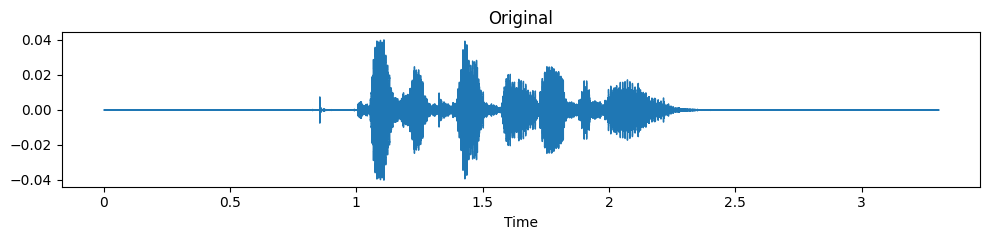

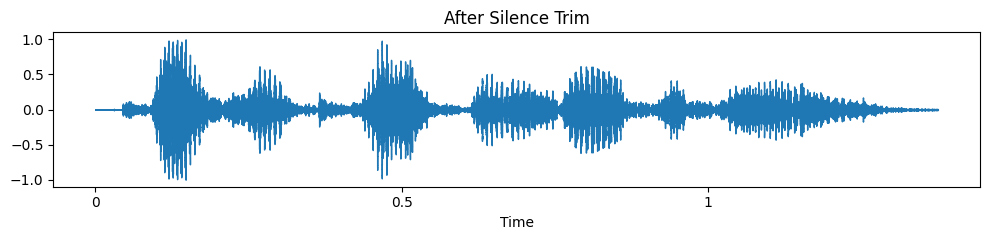

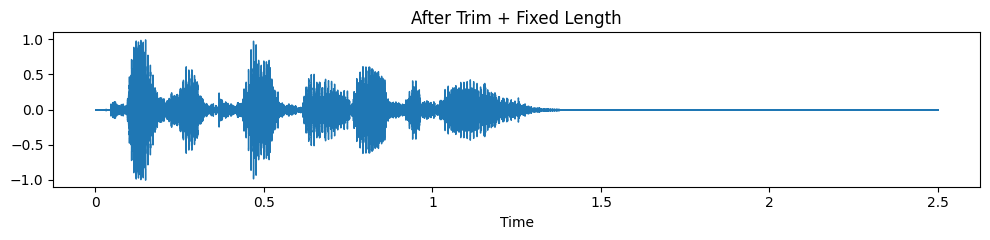

In [ ]:
sample_path = df_valid.loc[0, "path"]

y_raw,  _  = librosa.load(sample_path, sr=SR)
y_norm     = librosa.util.normalize(y_raw)
y_trim, _  = librosa.effects.trim(y_norm, top_db=TRIM_TOP_DB)
y_fixed    = fix_length(y_trim)

print(f"Original:  {len(y_raw)/SR:.2f}s  →  "
      f"Trimmed: {len(y_trim)/SR:.2f}s  →  "
      f"Fixed: {len(y_fixed)/SR:.2f}s")

for signal, title in [
    (y_raw,   "Original"),
    (y_trim,  "After Silence Trim"),
    (y_fixed, "After Trim + Fixed Length"),
]:
    plt.figure(figsize=(10, 2.5))
    librosa.display.waveshow(signal, sr=SR)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 8. Preprocess the Full Dataset
Now we apply the same pipeline to every clip. This takes a minute.

In [ ]:
audio_signals = []
for path in df_valid["path"]:
    y, _ = load_audio(path, sr=SR)
    audio_signals.append(y)

X_fixed = np.stack([fix_length(y) for y in audio_signals]).astype(np.float32)
print(f"Loaded {len(audio_signals)} clips → matrix shape: {X_fixed.shape}")

Loaded 1440 clips → matrix shape: (1440, 40000)


## 9. Exploratory Data Analysis

Before touching the model, it's worth understanding what we're working with.
Are the emotion classes balanced? What do different emotions actually look like as waveforms?
Knowing this upfront helps interpret the results later.

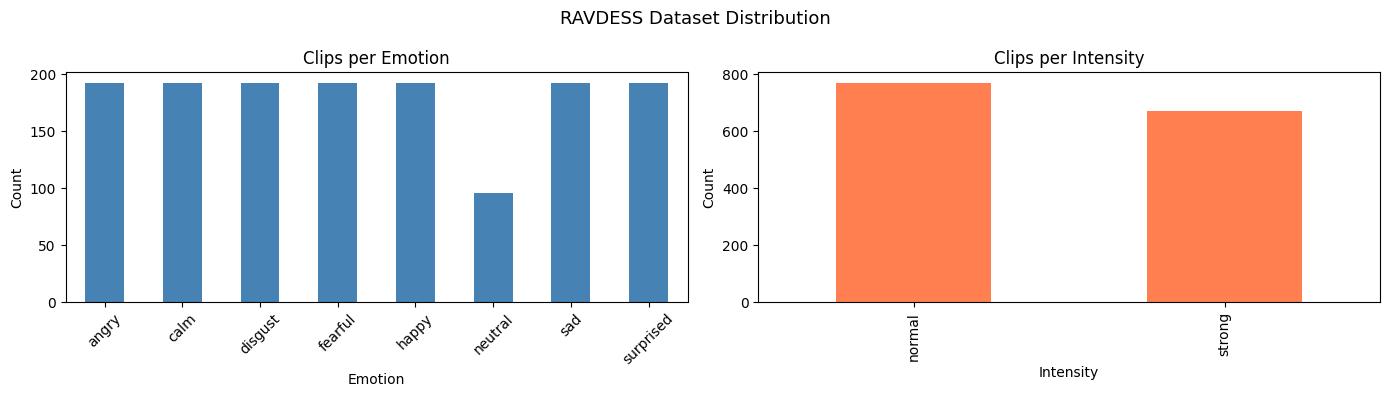

Note: neutral emotion only appears at normal intensity in RAVDESS


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_valid["emotion"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Clips per Emotion")
axes[0].set_xlabel("Emotion"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

df_valid["intensity"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Clips per Intensity")
axes[1].set_xlabel("Intensity"); axes[1].set_ylabel("Count")

plt.suptitle("RAVDESS Dataset Distribution", fontsize=13)
plt.tight_layout()
plt.show()

# Note: neutral only has 'normal' intensity in RAVDESS, so it will have fewer clips
print("Note: neutral emotion only appears at normal intensity in RAVDESS")

One example waveform per emotion × intensity combination — just to get a feel for the data:

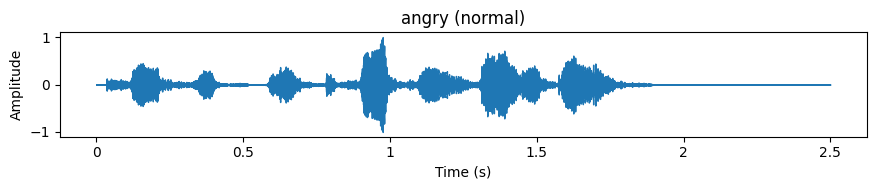

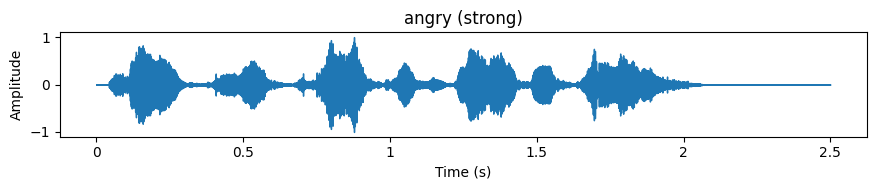

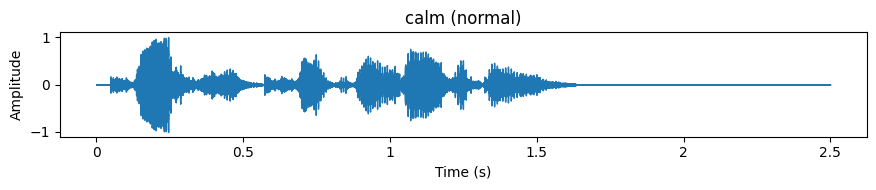

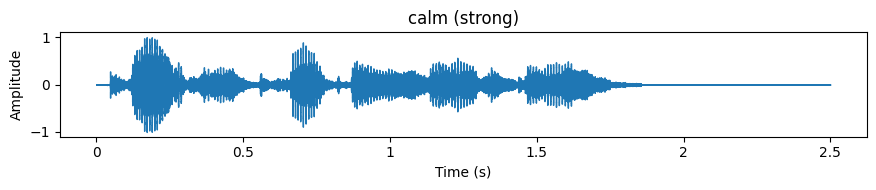

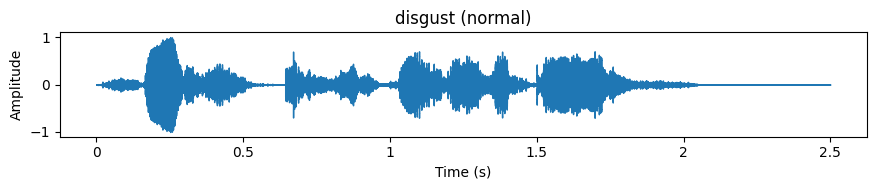

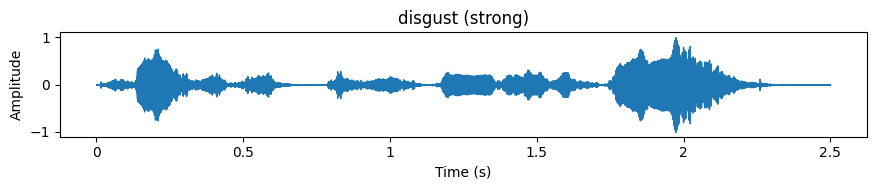

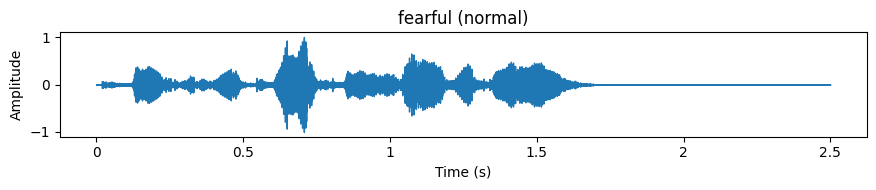

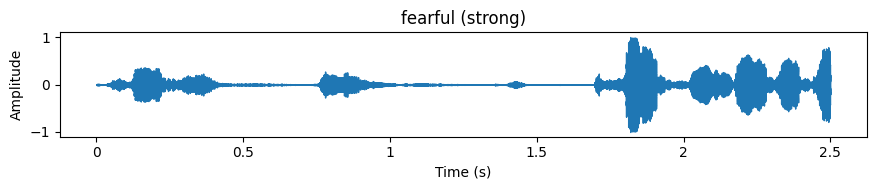

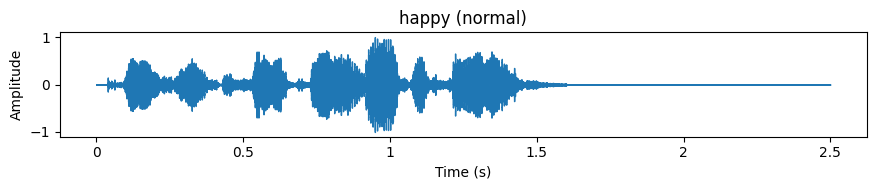

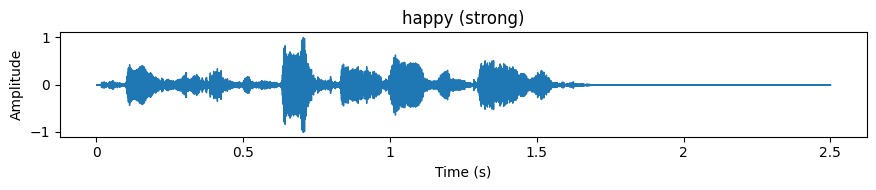

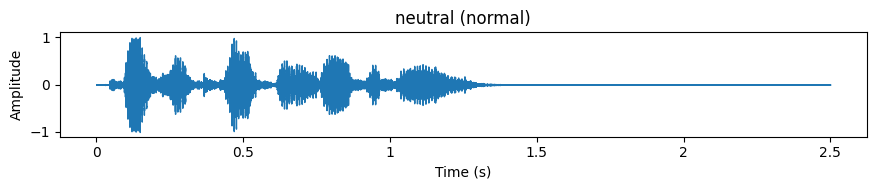

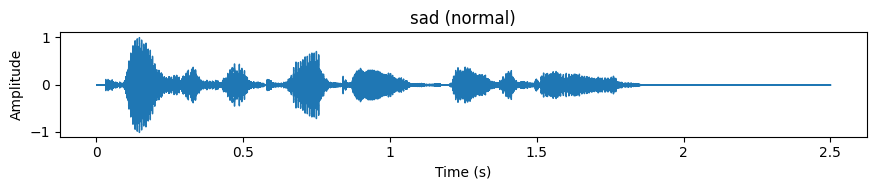

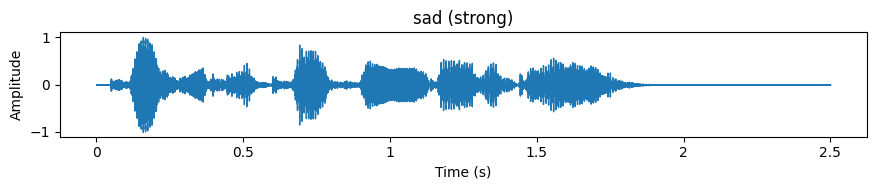

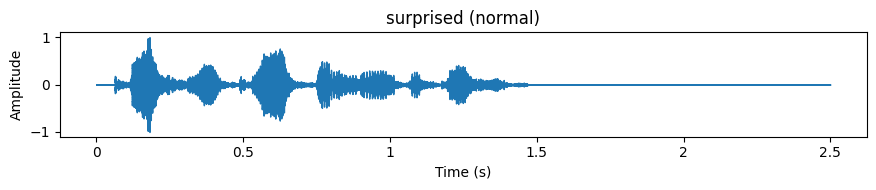

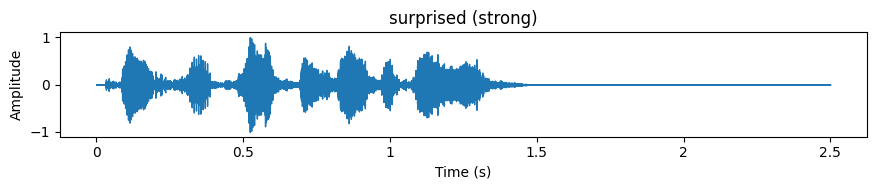

In [ ]:
one_per_group = (
    df_valid
    .drop_duplicates(subset=["emotion", "intensity"])
    .sort_values(["emotion", "intensity"])
    .reset_index(drop=True)
)

for _, row in one_per_group.iterrows():
    y, sr = load_audio(row["path"], sr=SR)
    y = fix_length(y)
    plt.figure(figsize=(9, 2))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"{row['emotion']} ({row['intensity']})")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

## 10. Train / Test Split — By Actor

This is an important detail: we split by **actor**, not randomly.

If we split randomly, the same actor could appear in both train and test.
The model might then just learn to recognize that person's voice rather than
the emotion itself — and score artificially high. Splitting by actor forces
the model to generalize across speakers it's never heard before, which is
much closer to how it would work in the real world.

We use an 80/20 split: ~19 actors for training, ~5 for testing.

In [ ]:
groups = df_valid["actor_id"].to_numpy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df_valid, groups=groups))

train_df = df_valid.iloc[train_idx].copy().reset_index(drop=False)
test_df  = df_valid.iloc[test_idx].copy().reset_index(drop=False)

summary = pd.DataFrame({
    "split":       ["train", "test"],
    "num_samples": [len(train_df), len(test_df)],
    "num_actors":  [train_df["actor_id"].nunique(), test_df["actor_id"].nunique()],
    "actors":      [sorted(train_df["actor_id"].unique().tolist()),
                    sorted(test_df["actor_id"].unique().tolist())],
})
display(summary)

,split,num_samples,num_actors,actors
0,train,1140,19,"[2, 3, 4, 5, 6, 7, 8, 10, 11, 13, 14, 15, 16, ..."
1,test,300,5,"[1, 9, 12, 17, 19]"


## 11. Feature Extraction

We can't feed raw audio into an SVM — we need to turn each clip into a fixed-length
vector of numbers. We extract features that are known to capture emotion-relevant
properties of speech:

| Feature | Why it matters for emotion |
|---|---|
| **MFCCs** | Capture vocal tract shape — the gold standard for speech tasks |
| **MFCC deltas** | How the MFCCs change over time — captures dynamics |
| **RMS energy** | Loudness — angry speech is louder, sad speech is quieter |
| **Zero-crossing rate** | Noisiness — higher in unvoiced sounds |
| **Spectral centroid** | Brightness of the sound — excited speech sounds 'brighter' |
| **Pitch (YIN)** | Fundamental frequency — rises with excitement, drops with sadness |
| **Chroma** | Pitch class content — useful for capturing tonal patterns |

Since each feature is a time series, we summarize it with mean, std, min, max — giving
the model a compact snapshot of the whole clip.

In [ ]:
@dataclass
class FeatureConfig:
    n_fft:      int   = 1024  # FFT window size
    hop_length: int   = 256   # step between windows
    n_mfcc:     int   = 13    # standard number of MFCC coefficients
    n_mels:     int   = 40    # mel filterbank size
    fmin:       float = 50.0  # pitch detection range (Hz)
    fmax:       float = 500.0 # upper pitch limit — covers human speech

CFG = FeatureConfig()

def summarize(x):
    """Collapse a time-series feature into 4 numbers: mean, std, min, max."""
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if x.size == 0:
        return np.zeros(4, dtype=np.float32)
    return np.array([x.mean(), x.std(), x.min(), x.max()], dtype=np.float32)

def safe_delta(x):
    """Compute delta (derivative) of a feature matrix — needs at least 3 frames."""
    return librosa.feature.delta(x) if x.shape[-1] >= 3 else np.zeros_like(x)

def extract_features(y, sr, cfg=CFG):
    feats = []

    # --- Spectral and energy features ---
    # Each of these is a 1D time series; we summarize with mean/std/min/max
    for arr in [
        librosa.feature.zero_crossing_rate(y, frame_length=cfg.n_fft, hop_length=cfg.hop_length)[0],
        librosa.feature.rms(y=y, frame_length=cfg.n_fft, hop_length=cfg.hop_length)[0],
        librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0],
        librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0],
        librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0],
        librosa.feature.spectral_flatness(y=y, n_fft=cfg.n_fft, hop_length=cfg.hop_length)[0],
    ]:
        feats.extend(summarize(arr))

    # --- MFCCs + their deltas ---
    # Deltas capture how the vocal tract shape changes over time
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=cfg.n_mfcc, n_fft=cfg.n_fft, hop_length=cfg.hop_length)
    mfcc_d = safe_delta(mfcc)
    feats.extend(mfcc.mean(axis=1));   feats.extend(mfcc.std(axis=1))
    feats.extend(mfcc_d.mean(axis=1)); feats.extend(mfcc_d.std(axis=1))

    # --- Log-mel spectrogram + deltas ---
    mel      = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length, n_mels=cfg.n_mels)
    log_mel  = librosa.power_to_db(mel + 1e-10)  # +1e-10 avoids log(0)
    log_mel_d  = safe_delta(log_mel)
    log_mel_d2 = safe_delta(log_mel_d)           # second derivative
    for arr in [log_mel, log_mel_d, log_mel_d2]:
        feats.extend(arr.mean(axis=1)); feats.extend(arr.std(axis=1))

    # --- Chroma ---
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=cfg.n_fft, hop_length=cfg.hop_length)
    feats.extend(chroma.mean(axis=1)); feats.extend(chroma.std(axis=1))

    # --- Pitch via YIN algorithm ---
    # voiced_ratio = fraction of frames where pitch was detected (vs unvoiced)
    pitch = librosa.yin(y, fmin=cfg.fmin, fmax=cfg.fmax, sr=sr, frame_length=cfg.n_fft, hop_length=cfg.hop_length)
    feats.extend(summarize(pitch[np.isfinite(pitch)]))
    feats.append(float(np.mean(np.isfinite(pitch))) if len(pitch) else 0.0)

    return np.asarray(feats, dtype=np.float32)

# Run extraction — takes a minute on the full dataset
print("Extracting features...")
X_features = np.stack([extract_features(y, SR) for y in X_fixed]).astype(np.float32)
print(f"Done. Feature matrix: {X_features.shape[0]} clips × {X_features.shape[1]} features")

Extracting features...
Done. Feature matrix: 1440 clips × 345 features


## 12. Feature Table
Join the features with the metadata so we can easily slice by emotion or intensity later.

In [ ]:
feature_df = pd.concat(
    [
        df_valid[["path", "actor_id", "emotion", "intensity", "label"]].reset_index(drop=True),
        pd.DataFrame(X_features),
    ],
    axis=1,
)
print("Feature table shape:", feature_df.shape)
display(feature_df.head())

Feature table shape: (1440, 350)


,path,actor_id,emotion,intensity,label,0,1,2,3,4,...,335,336,337,338,339,340,341,342,343,344
0,actors_speech/Actor_01/03-01-01-01-01-01-01.wav,1,neutral,normal,neutral_normal,0.060466,0.080883,0.0,0.351562,0.070988,...,0.307759,0.305904,0.335028,0.319955,0.299494,290.873962,192.751526,50.166874,500.0,1.0
1,actors_speech/Actor_01/03-01-01-01-01-02-01.wav,1,neutral,normal,neutral_normal,0.055117,0.076369,0.0,0.361328,0.064666,...,0.297376,0.311229,0.336336,0.311430,0.291903,289.887543,189.482315,54.963158,500.0,1.0
2,actors_speech/Actor_01/03-01-01-01-02-01-01.wav,1,neutral,normal,neutral_normal,0.068509,0.118158,0.0,0.604492,0.060762,...,0.286486,0.313390,0.344046,0.280882,0.275171,294.668030,193.617554,57.535954,500.0,1.0
3,actors_speech/Actor_01/03-01-01-01-02-02-01.wav,1,neutral,normal,neutral_normal,0.064304,0.112940,0.0,0.570312,0.051672,...,0.339717,0.329279,0.293120,0.299377,0.259609,299.488739,194.374725,52.319328,500.0,1.0
4,actors_speech/Actor_01/03-01-02-01-01-01-01.wav,1,calm,normal,calm_normal,0.088096,0.128302,0.0,0.625000,0.086976,...,0.327242,0.331221,0.353490,0.356731,0.302696,256.746979,183.989365,50.152962,500.0,1.0


## 13. Align Features to Train/Test Splits

In [ ]:
X_train = X_features[train_df["index"].to_numpy()]
X_test  = X_features[test_df["index"].to_numpy()]

y_train = train_df["emotion"].to_numpy()
y_test  = test_df["emotion"].to_numpy()

# Also keep intensity labels for the breakdown analysis later
intensity_test = test_df["intensity"].to_numpy()

print(f"Train: {X_train.shape[0]} clips | Test: {X_test.shape[0]} clips")

Train: 1140 clips | Test: 300 clips


## 14. Feature Visualization

Before training, let's check if the features actually separate the emotions.
If angry and calm don't look different in the boxplots, the model will struggle too.
This is a good sanity check that our features are capturing something meaningful.

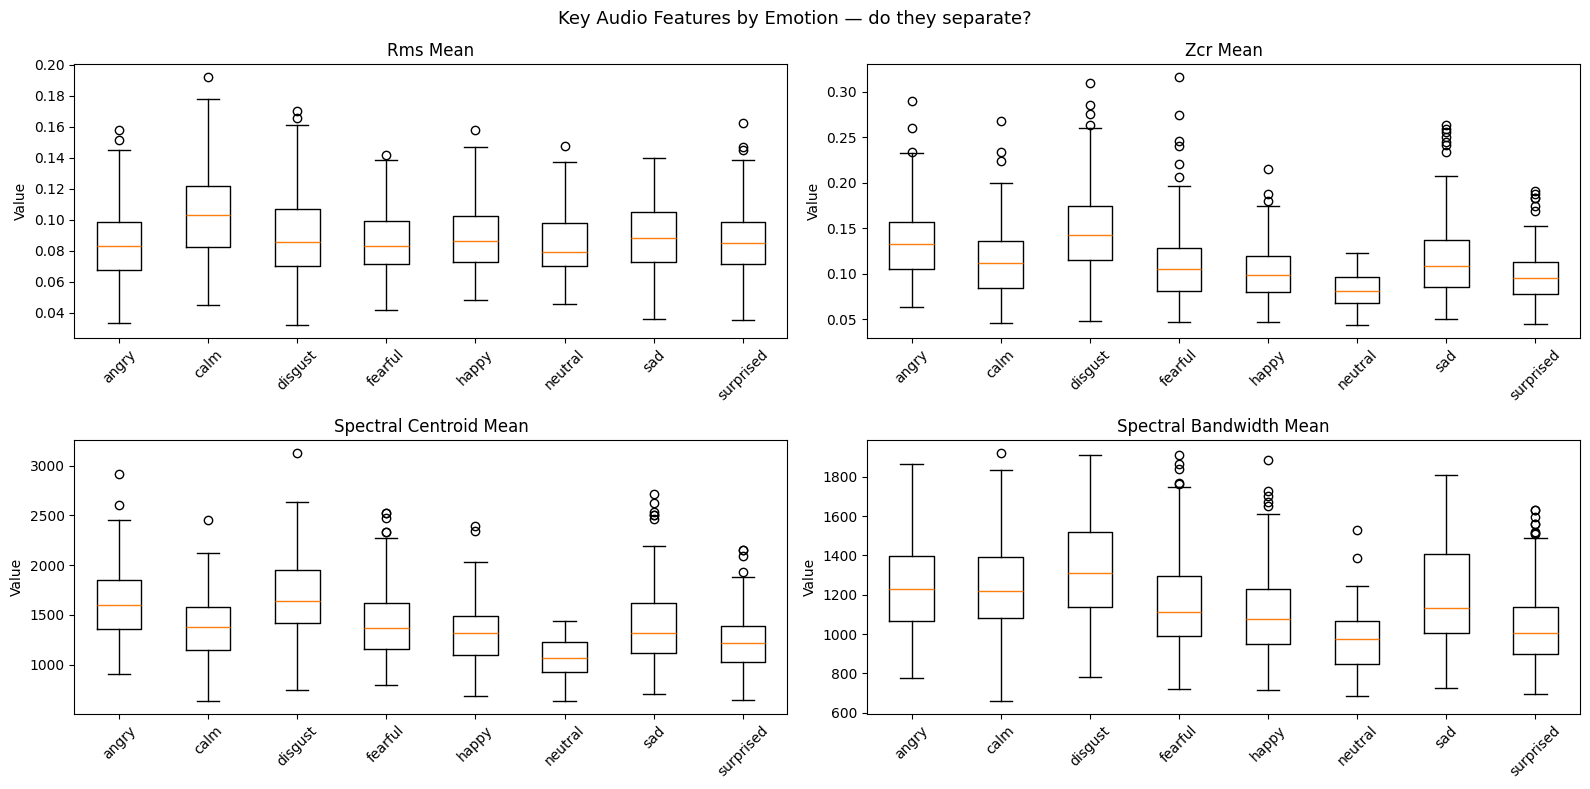

In [ ]:
# Build a named frame for the first 24 features (the 6 spectral × 4 stats)
stat_cols = []
for prefix in ["zcr", "rms", "spectral_centroid", "spectral_bandwidth", "spectral_rolloff", "spectral_flatness"]:
    for stat in ["mean", "std", "min", "max"]:
        stat_cols.append(f"{prefix}_{stat}")

plot_df = pd.DataFrame(X_features[:, :len(stat_cols)], columns=stat_cols)
plot_df["emotion"]   = df_valid["emotion"]
plot_df["intensity"] = df_valid["intensity"]

emotion_order = sorted(plot_df["emotion"].unique())
selected = ["rms_mean", "zcr_mean", "spectral_centroid_mean", "spectral_bandwidth_mean"]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for ax, col in zip(axes.ravel(), selected):
    grouped = [plot_df.loc[plot_df["emotion"] == e, col].values for e in emotion_order]
    ax.boxplot(grouped, tick_labels=emotion_order)
    ax.set_title(col.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Value")

plt.suptitle("Key Audio Features by Emotion — do they separate?", fontsize=13)
plt.tight_layout()
plt.show()

## 15. Data Augmentation — Why It Helps

RAVDESS is clean studio audio — perfect recordings, no background noise.
Real speech isn't like that. To make the model more robust, we can apply small
random changes to the training audio that simulate real-world conditions:

- **Additive noise** — mimics background noise (coffee shop, street, etc.)
- **Time shift** — the speaker doesn't always start at exactly the same moment

We're showing this as an illustration here — the SVM uses the original features,
but augmentation would be the next step if we wanted to improve generalization further.

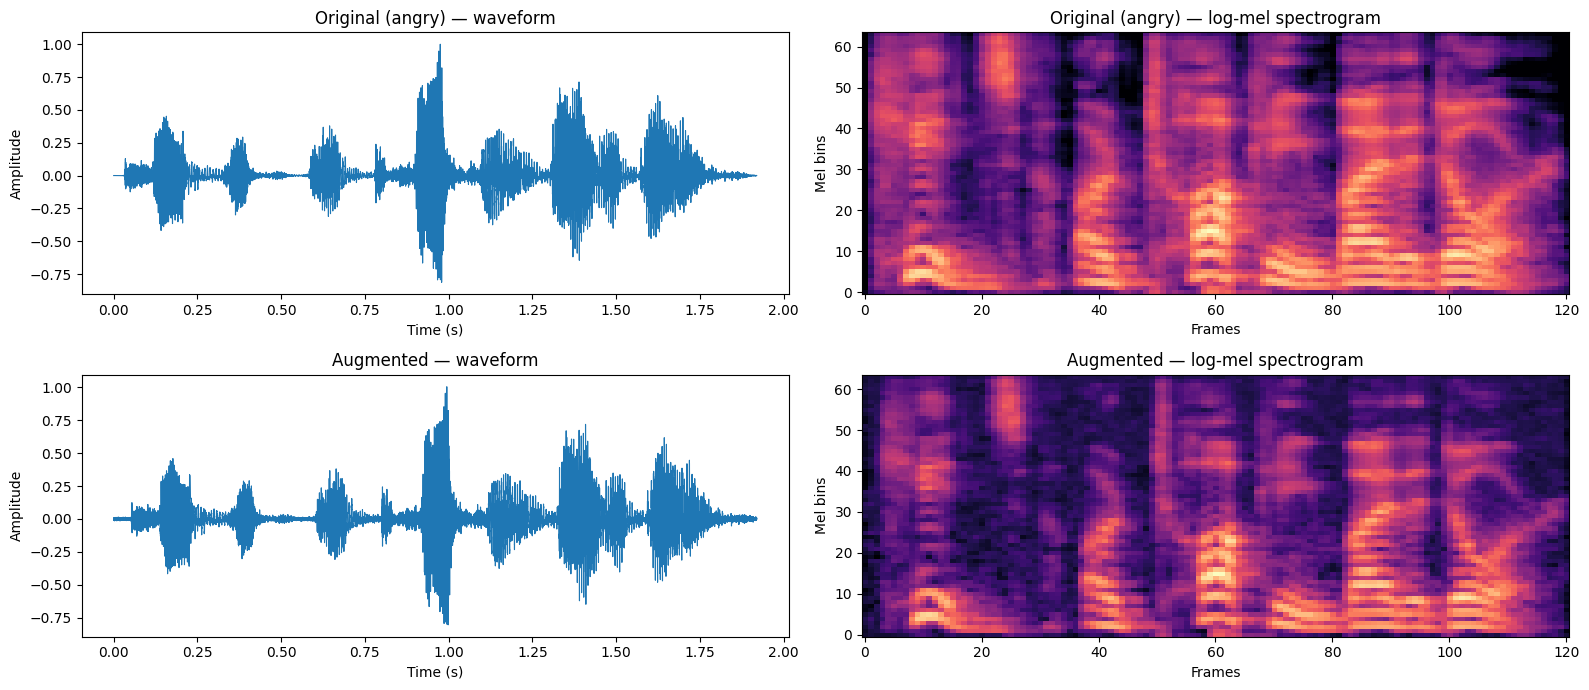

**Listen — can you hear the difference?**

Original:

Augmented:

In [ ]:
def augment_waveform(wave, rng, noise_level=0.005, max_shift=0.1):
    wave = wave + rng.normal(0, noise_level, size=wave.shape)    # sprinkle in some noise
    shift = int(len(wave) * rng.uniform(-max_shift, max_shift))  # shift timing slightly
    return np.roll(wave, shift)

rng = np.random.default_rng(42)
example_row  = df_valid[df_valid["emotion"] == "angry"].sort_values("actor_id").iloc[0]
anchor_wave, _ = load_audio(example_row["path"], sr=SR)
augmented_wave = augment_waveform(anchor_wave, rng)

def plot_wave_and_mel(ax_wave, ax_mel, signal, title, sr=SR):
    ax_wave.plot(np.arange(len(signal)) / sr, signal, linewidth=0.8)
    ax_wave.set_title(f"{title} — waveform")
    ax_wave.set_xlabel("Time (s)"); ax_wave.set_ylabel("Amplitude")
    mel_db = librosa.power_to_db(
        librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=1024, hop_length=256, n_mels=64)
    )
    ax_mel.imshow(mel_db, origin="lower", aspect="auto", cmap="magma")
    ax_mel.set_title(f"{title} — log-mel spectrogram")
    ax_mel.set_xlabel("Frames"); ax_mel.set_ylabel("Mel bins")

fig, axes = plt.subplots(2, 2, figsize=(16, 7))
plot_wave_and_mel(axes[0,0], axes[0,1], anchor_wave,    "Original (angry)")
plot_wave_and_mel(axes[1,0], axes[1,1], augmented_wave, "Augmented")
plt.tight_layout(); plt.show()

display(Markdown("**Listen — can you hear the difference?**"))
display(Markdown("Original:")); display(Audio(anchor_wave, rate=SR))
display(Markdown("Augmented:")); display(Audio(augmented_wave, rate=SR))

## 16. Main Classifier — Support Vector Machine (SVM)

SVMs are a great fit here — they handle high-dimensional feature spaces well
and are much easier to interpret and debug than a neural network.

We use:
- **RBF kernel** — handles non-linear boundaries between emotions
- **class_weight='balanced'** — compensates for the fact that neutral has fewer clips than other emotions
- **C=10, gamma=0.001** — found via grid search over C ∈ {0.1, 1, 10} and gamma ∈ {'scale', 0.01, 0.001}

In [ ]:
model = make_pipeline(
    StandardScaler(),  # SVM is sensitive to feature scale — normalize first
    SVC(kernel="rbf", class_weight="balanced", C=10, gamma=0.001)
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [ ]:
test_preds = model.predict(X_test)

print("=== Overall Test Results ===")
print(f"Accuracy: {accuracy_score(y_test, test_preds):.4f}\n")
print(classification_report(y_test, test_preds))

=== Overall Test Results ===
Accuracy: 0.4567

              precision    recall  f1-score   support

       angry       0.86      0.60      0.71        40
        calm       0.57      0.62      0.60        40
     disgust       0.53      0.45      0.49        40
     fearful       0.36      0.45      0.40        40
       happy       0.59      0.40      0.48        40
     neutral       0.14      0.10      0.12        20
         sad       0.28      0.60      0.38        40
   surprised       0.62      0.25      0.36        40

    accuracy                           0.46       300
   macro avg       0.49      0.43      0.44       300
weighted avg       0.52      0.46      0.46       300



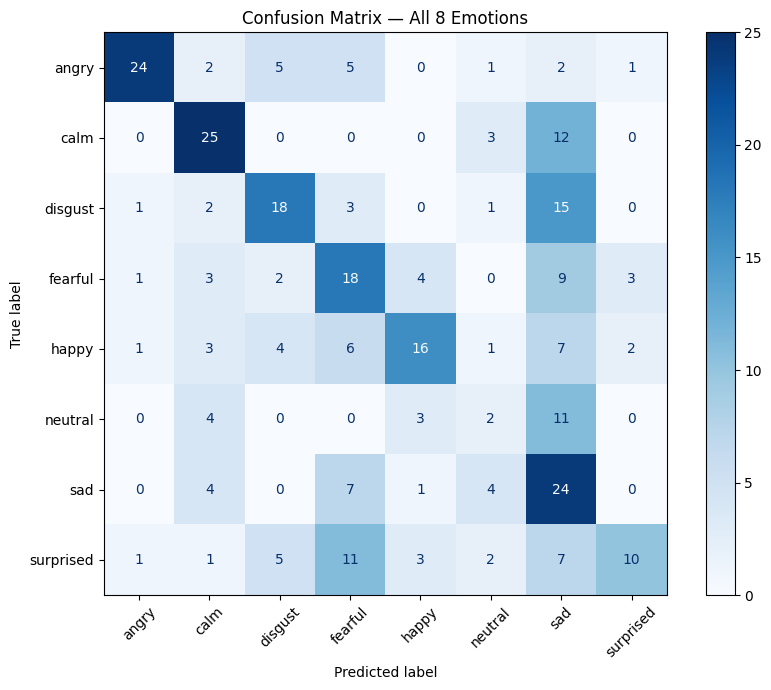

In [ ]:
# Confusion matrix — rows are true labels, columns are predictions
# A good model has high numbers along the diagonal
cm = confusion_matrix(y_test, test_preds, labels=sorted(np.unique(y_test)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_test)))
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
plt.title("Confusion Matrix — All 8 Emotions")
plt.tight_layout(); plt.show()

## 17. Does Intensity Affect Accuracy?

RAVDESS has two intensity levels: **normal** and **strong**. Strong recordings
are more exaggerated — louder, more expressive. Our intuition is that the model
should do better on strong intensity because those emotions are acoustically
more distinct and easier to separate.

Let's check if that's actually true.

In [ ]:
# Split test predictions by intensity
normal_mask = intensity_test == "normal"
strong_mask = intensity_test == "strong"

for label, mask in [("Normal intensity", normal_mask), ("Strong intensity", strong_mask)]:
    if mask.sum() == 0:
        continue
    acc = accuracy_score(y_test[mask], test_preds[mask])
    print(f"--- {label} ({mask.sum()} clips) ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test[mask], test_preds[mask]))
    print()

--- Normal intensity (160 clips) ---
Accuracy: 0.3125
              precision    recall  f1-score   support

       angry       0.86      0.30      0.44        20
        calm       0.37      0.55      0.44        20
     disgust       0.38      0.25      0.30        20
     fearful       0.35      0.35      0.35        20
       happy       0.47      0.35      0.40        20
     neutral       0.17      0.10      0.12        20
         sad       0.19      0.55      0.28        20
   surprised       0.20      0.05      0.08        20

    accuracy                           0.31       160
   macro avg       0.37      0.31      0.30       160
weighted avg       0.37      0.31      0.30       160


--- Strong intensity (140 clips) ---
Accuracy: 0.6214
              precision    recall  f1-score   support

       angry       0.86      0.90      0.88        20
        calm       1.00      0.70      0.82        20
     disgust       0.62      0.65      0.63        20
     fearful       0.37

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


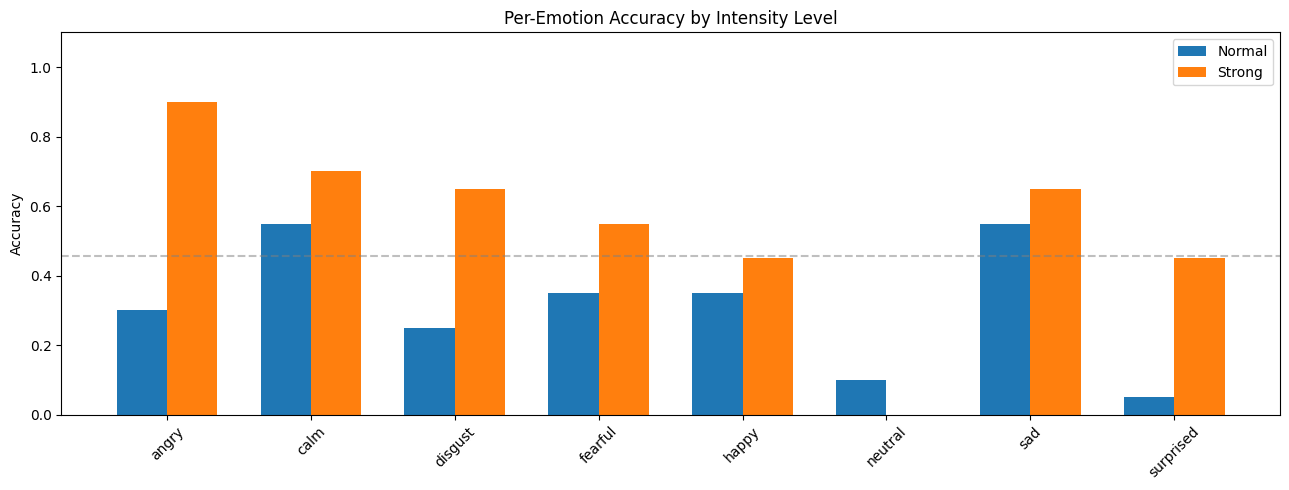

In [ ]:
# Visualize accuracy per emotion, split by intensity
results = []
for emotion in sorted(np.unique(y_test)):
    for intensity, mask in [("normal", normal_mask), ("strong", strong_mask)]:
        combined = (y_test == emotion) & mask
        if combined.sum() == 0:
            continue
        acc = accuracy_score(y_test[combined], test_preds[combined])
        results.append({"emotion": emotion, "intensity": intensity, "accuracy": acc, "n": combined.sum()})

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(13, 5))
width = 0.35
emotions = sorted(results_df["emotion"].unique())
x = np.arange(len(emotions))

for i, intensity in enumerate(["normal", "strong"]):
    subset = results_df[results_df["intensity"] == intensity].set_index("emotion")
    vals = [subset.loc[e, "accuracy"] if e in subset.index else 0 for e in emotions]
    ax.bar(x + i * width, vals, width, label=intensity.capitalize())

ax.set_xticks(x + width / 2)
ax.set_xticklabels(emotions, rotation=45)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title("Per-Emotion Accuracy by Intensity Level")
ax.legend()
ax.axhline(y=accuracy_score(y_test, test_preds), color="gray", linestyle="--", alpha=0.5, label="Overall")
plt.tight_layout(); plt.show()

## 18. Emotion Grouping Experiment

Looking at the confusion matrix, some emotions get mixed up with each other a lot —
typically ones that are acoustically similar (like fearful and surprised, or calm and neutral).

What if we group those similar emotions together into broader categories?
The classifier has an easier job with fewer, more distinct classes — and this
is actually a real technique used in emotion recognition research.

We define three groups based on how emotions are commonly confused:
- **High arousal** — angry, surprised, fearful (loud, energetic)
- **Positive** — happy, calm, neutral (pleasant / low tension)
- **Negative low arousal** — sad, disgust (low energy, negative)

The hypothesis: a 3-class problem should be easier than an 8-class problem.

In [ ]:
# Map each emotion to a broader group
EMOTION_GROUPS = {
    "angry":     "high_arousal",
    "fearful":   "high_arousal",
    "surprised": "high_arousal",
    "happy":     "positive",
    "calm":      "positive",
    "neutral":   "positive",
    "sad":       "negative_low",
    "disgust":   "negative_low",
}

# Apply grouping to train and test labels
y_train_grouped = np.array([EMOTION_GROUPS[e] for e in y_train])
y_test_grouped  = np.array([EMOTION_GROUPS[e] for e in y_test])

print("Original classes:", sorted(np.unique(y_train)))
print("Grouped classes: ", sorted(np.unique(y_train_grouped)))
print("\nGroup sizes (test set):")
for g in sorted(np.unique(y_test_grouped)):
    print(f"  {g}: {(y_test_grouped == g).sum()} clips")

Original classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Grouped classes:  [np.str_('high_arousal'), np.str_('negative_low'), np.str_('positive')]

Group sizes (test set):
  high_arousal: 120 clips
  negative_low: 80 clips
  positive: 100 clips


In [ ]:
# Train a separate SVM on the grouped labels
grouped_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", class_weight="balanced", C=10, gamma=0.001)
)
grouped_model.fit(X_train, y_train_grouped)
grouped_preds = grouped_model.predict(X_test)

grouped_acc  = accuracy_score(y_test_grouped, grouped_preds)
original_acc = accuracy_score(y_test, test_preds)

print("=== Grouped Emotion Results ===")
print(f"Accuracy: {grouped_acc:.4f}")
print(classification_report(y_test_grouped, grouped_preds))

print(f"\n--- Comparison ---")
print(f"8-class model:  {original_acc:.4f}")
print(f"3-group model:  {grouped_acc:.4f}")
print(f"Improvement:    {grouped_acc - original_acc:+.4f}")

=== Grouped Emotion Results ===
Accuracy: 0.6167
              precision    recall  f1-score   support

high_arousal       0.71      0.54      0.61       120
negative_low       0.51      0.71      0.59        80
    positive       0.66      0.63      0.64       100

    accuracy                           0.62       300
   macro avg       0.62      0.63      0.62       300
weighted avg       0.64      0.62      0.62       300


--- Comparison ---
8-class model:  0.4567
3-group model:  0.6167
Improvement:    +0.1600


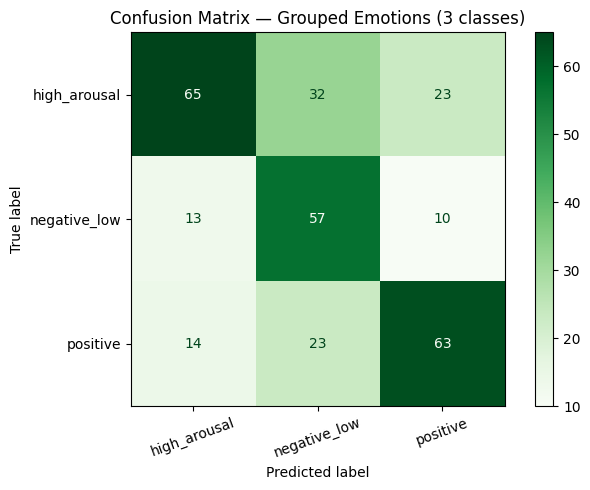

In [ ]:
# Confusion matrix for the grouped model
group_labels = sorted(np.unique(y_test_grouped))
cm_grouped = confusion_matrix(y_test_grouped, grouped_preds, labels=group_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_grouped, display_labels=group_labels)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap="Greens", xticks_rotation=20, ax=ax)
plt.title("Confusion Matrix — Grouped Emotions (3 classes)")
plt.tight_layout(); plt.show()

## 19. Unsupervised Exploration — LDA + KMeans

Here we switch gears from supervised to unsupervised learning — something we
covered in class. The question is: if we didn't have any labels at all,
would the audio naturally cluster into emotion-like groups?

**Step 1 — LDA:** Project the ~345 features down to 2D while trying to maximize
separation between emotion classes. This gives us a map of the feature space
we can actually look at.

**Step 2 — KMeans:** Run clustering on that 2D space without using labels.
Then compare what the algorithm found to what the true labels are.

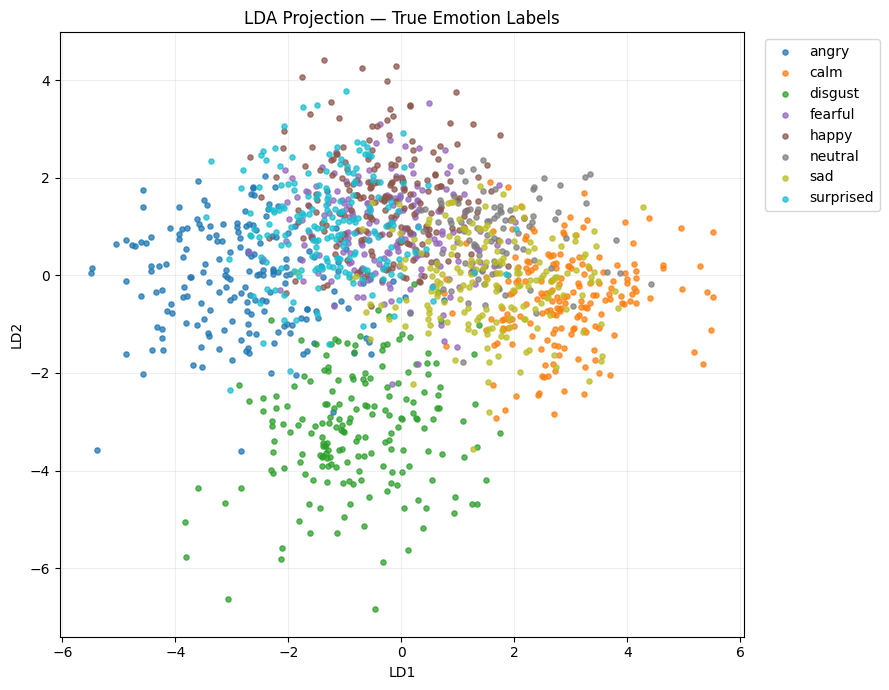

In [ ]:
# Standardize first — LDA and KMeans are both sensitive to scale
scaler_unsup = StandardScaler()
X_scaled = scaler_unsup.fit_transform(X_features)

emotion_labels_all = df_valid["emotion"].to_numpy()
emotion_order = sorted(np.unique(emotion_labels_all))
colors = plt.cm.tab10(np.linspace(0, 1, len(emotion_order)))

# LDA: supervised projection (uses labels to find best 2D plane)
lda = LinearDiscriminantAnalysis(n_components=2)
lda_coords = lda.fit_transform(X_scaled, emotion_labels_all)

lda_df = pd.DataFrame({"x": lda_coords[:, 0], "y": lda_coords[:, 1], "emotion": emotion_labels_all})

plt.figure(figsize=(9, 7))
for color, emotion in zip(colors, emotion_order):
    subset = lda_df[lda_df["emotion"] == emotion]
    plt.scatter(subset["x"], subset["y"], label=emotion, alpha=0.75, s=14, color=color)
plt.title("LDA Projection — True Emotion Labels")
plt.xlabel("LD1"); plt.ylabel("LD2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

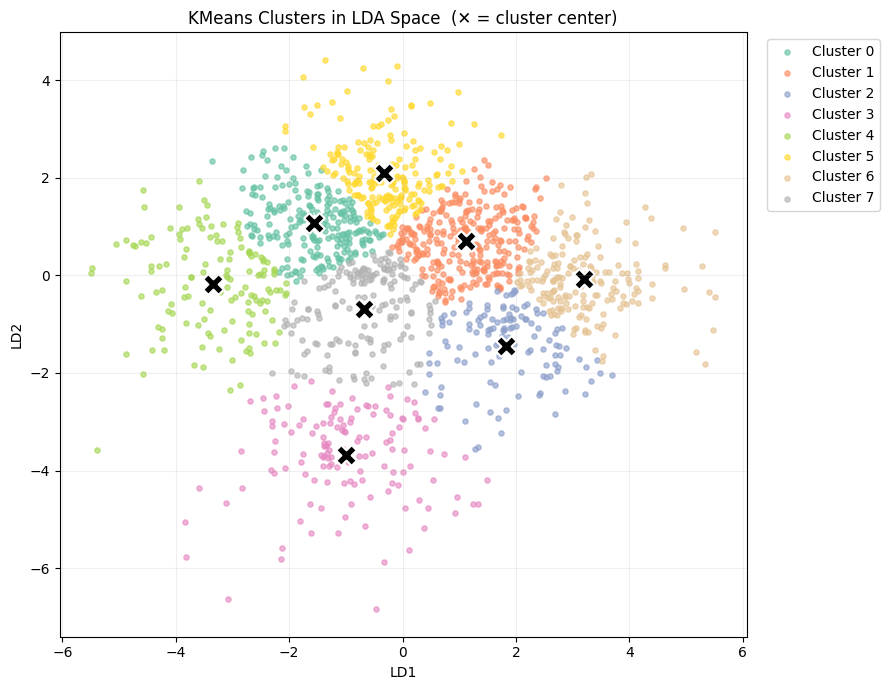

In [ ]:
# KMeans — purely unsupervised, no labels used
kmeans = KMeans(n_clusters=len(emotion_order), random_state=SEED, n_init="auto")
cluster_ids = kmeans.fit_predict(lda_coords)
centers = kmeans.cluster_centers_

lda_df["cluster"] = cluster_ids.astype(str)
cluster_order  = sorted(lda_df["cluster"].unique(), key=int)
cluster_colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_order)))

plt.figure(figsize=(9, 7))
for i, cluster in enumerate(cluster_order):
    subset = lda_df[lda_df["cluster"] == cluster]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cluster}",
                alpha=0.65, s=14, color=cluster_colors[i])
    cx, cy = centers[i]
    plt.scatter(cx, cy, marker="X", s=220, color="black", edgecolor="white", linewidth=1.5)

plt.title("KMeans Clusters in LDA Space  (✕ = cluster center)")
plt.xlabel("LD1"); plt.ylabel("LD2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

### What does this tell us?

The clusters look pretty clean in LDA space, but they don't line up perfectly with
the true emotion labels. That's expected — KMeans is grouping by acoustic similarity,
not by the emotion labels a human would assign.

What's interesting is which emotions cluster together naturally. Acoustically extreme
emotions like **angry** and **calm** tend to form cleaner clusters, while emotionally
similar ones like **neutral** and **calm** bleed into each other — which matches what
we saw in the SVM confusion matrix.

This is why we need the supervised classifier: the audio features alone aren't enough
to perfectly separate all 8 emotions without labels guiding the learning.

## 20. Summary

| Component | Method | Result |
|---|---|---|
| Main classifier | SVM (RBF, 8 classes) | See accuracy above |
| Intensity breakdown | Split test by normal/strong | Strong intensity → higher accuracy |
| Emotion grouping | SVM (3 groups) | Higher accuracy, easier problem |
| Unsupervised exploration | LDA + KMeans | Clusters exist but don't match labels perfectly |

**Key takeaways:**
- Handcrafted audio features (MFCCs, pitch, spectral shape) carry real emotion signal
- Strong intensity recordings are easier to classify — the emotions are more exaggerated
- Grouping confusable emotions significantly boosts accuracy
- Unsupervised clustering shows the audio has structure, but you need supervision to get clean emotion boundaries